# SAE estimations for MPI in Cambodia

In [23]:
#Imports  
import pandas as pd
import geopandas as gpd
import os 
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Parameters
nis_year = 2021
dhs_year = 2021

#Load NIS information
#These files contain the variable equivalence between the NIS and DHS datasets. 
common_variables_path = f'data/common_variables.xlsx'
common_variables = pd.read_excel(common_variables_path)

### Load NIS data

In [25]:
nis_raw_data_path = f'data/NIS{nis_year}_Village_Year_Coords.xlsx'
nis_mpi_data_path = f'data/MPI_NIS_{nis_year}.xlsx'

nis_columns = common_variables['NIS_code'].to_list() #Only load the MPI related columns 
nis_columns = [x for x in nis_columns if not pd.isna(x)] #Drop nan to load the file properly
nis = pd.read_excel(nis_mpi_data_path)#, usecols=nis_columns)

In [26]:
#Read villages shape file
villages_path = r'data/Villages.shp'
villages = gpd.read_file(villages_path)

In [27]:
nis = villages[['PHUMCODE','geometry']].merge(nis, left_on='PHUMCODE', right_on='VillGis', how='right')

In [28]:
nis = nis[['PHUMCODE', 	'geometry'] + nis_columns]

### Load DHS data

In [29]:
#Load DHS  (rate indicators (Methodology 4): households deprived out of the total number of households per psu) 
dhs_path = f'data/mpi_met4_dhs21-22.csv'
dhs = pd.read_csv(dhs_path)

In [30]:
dhs.head()

,psu,area,region,region_01,rate_cm,rate_nutr,rate_satt,rate_educ,rate_elct,rate_wtr,...,depr_nutr,depr_educ,depr_satt,depr_wtr,depr_sani,depr_hsg,depr_elct,depr_asst,depr_ckfl,mpi_met4
0,1,urban,Banteay Meanchay,Banteay Meanchay,0.0,0.214286,0.200000,0.200000,0.0,0.000000,...,1,1,1,0,0,0,0,0,1,0.555556
1,2,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.083333,0.076923,0.076923,0.0,0.076923,...,0,0,0,0,0,0,0,0,1,0.055556
2,3,urban,Banteay Meanchay,Banteay Meanchay,0.0,0.071429,0.071429,0.214286,0.0,0.000000,...,0,1,0,0,0,0,0,0,1,0.222222
3,4,urban,Banteay Meanchay,Banteay Meanchay,0.0,0.142857,0.133333,0.133333,0.0,0.000000,...,1,1,0,0,0,0,0,0,1,0.388889
4,5,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.066667,0.066667,0.333333,0.0,0.000000,...,0,1,0,0,0,0,0,0,1,0.222222


In [31]:
selected_dhs_variables = ['psu', 'area', 'region', 'region_01', 'rate_cm', 'rate_nutr', 'rate_satt', 'rate_educ', 'rate_elct', 'rate_wtr', 'rate_sani', 'rate_hsg', 'rate_ckfl', 'rate_asst']


In [32]:
#Attach cluster geometries to DHS cluster-level data (DHS)
dhs_shape_path = f'data/mpi_khm_dhs21-22_hmn_clust_CI_mis.shp'
dhs_shape = gpd.read_file(dhs_shape_path)

In [33]:
dhs_shape.head()

,DHSID,DHSCC,DHSYEAR,DHSCLUST,CCFIPS,ADM1FIPS,ADM1FIPSNA,ADM1SALBNA,ADM1SALBCO,ADM1DHS,...,mpi_0_SE,mpi_0_loCI,mpi_0_upCI,mpi_3,mpi_3_SE,mpi_3_loCI,mpi_3_upCI,tot_ppl,pct_pplmis,geometry
0,KH202100000001,KH,2021.0,1.0,CB,NULL,NULL,NULL,NULL,1.0,...,0.033871,0.060728,0.207078,0.039886,0.031522,-0.028213,0.107985,84,7.142860,POINT (103.02799 13.4683)
1,KH202100000002,KH,2021.0,2.0,CB,NULL,NULL,NULL,NULL,1.0,...,0.027919,0.038088,0.160986,0.000000,NaN,NaN,NaN,53,9.433961,POINT (102.93109 13.45718)
2,KH202100000003,KH,2021.0,3.0,CB,NULL,NULL,NULL,NULL,1.0,...,0.024514,0.038959,0.144879,0.000000,NaN,NaN,NaN,55,0.000000,POINT (103.01857 13.41292)
3,KH202100000004,KH,2021.0,4.0,CB,NULL,NULL,NULL,NULL,1.0,...,0.023474,0.042763,0.144186,0.000000,NaN,NaN,NaN,69,8.695650,POINT (103.03662 13.5421)
4,KH202100000005,KH,2021.0,5.0,CB,NULL,NULL,NULL,NULL,1.0,...,0.043984,0.035900,0.224574,0.068306,0.047890,-0.034407,0.171019,61,0.000000,POINT (102.95391 13.37782)


In [34]:
dhs_shape.columns.tolist()

['DHSID',
 'DHSCC',
 'DHSYEAR',
 'DHSCLUST',
 'CCFIPS',
 'ADM1FIPS',
 'ADM1FIPSNA',
 'ADM1SALBNA',
 'ADM1SALBCO',
 'ADM1DHS',
 'ADM1NAME',
 'DHSREGCO',
 'DHSREGNA',
 'SOURCE',
 'URBAN_RURA',
 'LATNUM',
 'LONGNUM',
 'ALT_GPS',
 'ALT_DEM',
 'DATUM',
 'clust_no',
 'area',
 'region',
 'mpi_0',
 'mpi_0_SE',
 'mpi_0_loCI',
 'mpi_0_upCI',
 'mpi_3',
 'mpi_3_SE',
 'mpi_3_loCI',
 'mpi_3_upCI',
 'tot_ppl',
 'pct_pplmis',
 'geometry']

In [35]:

#Drop almos zero coordinates
# Define a small threshold for "almost zero"
epsilon = 1e-10

# Filter out points near (0, 0)
dhs_shape = dhs_shape[~(
    (np.abs(dhs_shape.geometry.x) < epsilon) &
    (np.abs(dhs_shape.geometry.y) < epsilon)
)]

In [36]:
#Keep only the rural clusters
dhs_shape = dhs_shape[dhs_shape['URBAN_RURA'] == 'R'] #Only rural clusters

In [37]:
dhs = dhs_shape[['DHSCLUST', 'geometry']].merge(dhs, right_on='psu', left_on='DHSCLUST', how='left')

In [38]:
dhs.head()

,DHSCLUST,geometry,psu,area,region,region_01,rate_cm,rate_nutr,rate_satt,rate_educ,...,depr_nutr,depr_educ,depr_satt,depr_wtr,depr_sani,depr_hsg,depr_elct,depr_asst,depr_ckfl,mpi_met4
0,2.0,POINT (102.93109 13.45718),2,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.083333,0.076923,0.076923,...,0,0,0,0,0,0,0,0,1,0.055556
1,5.0,POINT (102.95391 13.37782),5,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.066667,0.066667,0.333333,...,0,1,0,0,0,0,0,0,1,0.222222
2,6.0,POINT (103.0777 13.56252),6,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.133333,0.000000,0.400000,...,1,1,0,0,0,0,0,0,1,0.388889
3,7.0,POINT (103.32516 13.78765),7,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.272727,0.000000,0.083333,...,1,0,0,0,0,0,0,0,1,0.222222
4,8.0,POINT (103.3093 13.76612),8,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.214286,0.071429,0.285714,...,1,1,0,0,0,0,0,0,1,0.388889


In [39]:
#Import the dictionary with the common variables
common_variables

,Description,DHS_code,Rate variable (methodology 4),Description.1,NIS_code,DUMMY
0,Household had child mortality under 18 in the ...,d_cm,rate_cm,Child mortality rate calculated as the proport...,523-C_MORT_RATE,536-C_MORT_DUM
1,Household has individuals malnourished,d_nutr,rate_nutr,NaN,NaN,NaN
2,Household has not all school age children up t...,d_satt,rate_satt,NaN,NaN,NaN
3,Household has less one member with 6 years of ...,d_educ,rate_educ,Illiterate population rate calculated as the p...,513-ILLITERATE_RATE,537-ILLIT_DUM
4,Household doesn't electricity,d_elct,rate_elct,Household with electricity rate calculated as ...,534-LQ_ROOF_ELEC_RATE,540-HOUSE_ELEC_DUM
5,"Household has roof, floor and walls with low q...",d_hsg,rate_hsg,Low quality material roofs rate calculated as ...,NaN,NaN
6,Household does not have drinking water with MD...,d_wtr,rate_wtr,"Rate of families with unimproved (pond, rivers...",517-UNIMPROV_WAT_RATE,538-UNIMPROV_WAT_DUM
7,Household does not improved sanitation with M...,d_sani,rate_sani,Household with latrines rate calculated as the...,532-Sanit_Rate,539-SANIT_DUM
8,Household does not accomplish cooking fuel by ...,d_ckfl,rate_ckfl,NaN,NaN,NaN
9,Household Asset Ownership: HH doesn't have car...,d_asst,rate_asst,Rate of assets owneship (mobility & agricultur...,531-AGRI_ASSETS_RATE,NaN


In [40]:
nis = nis[nis.geometry.notnull()] #Exclude null geometries
print(nis["geometry"].duplicated().sum()) #Check if there are null geometries
print(nis["PHUMCODE"].duplicated().sum()) #Check if there are duplicated PHUMCODE

3
0


In [41]:
dhs = dhs.to_crs(nis.crs)

In [42]:
dhs.to_file(fr'data/underlying/sae-dhs-underlying-{dhs_year}.shp')


In [43]:
nis.to_file(fr'data/underlying/sae-nis-complete-{nis_year}.shp')

C:\Users\nicol\AppData\Local\Temp\ipykernel_5596\2927337131.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nis.to_file(fr'data/underlying/sae-nis-complete-{nis_year}.shp')
c:\Users\nicol\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: '523-C_MORT_RATE' to '523-C_MORT'
  ogr_write(
c:\Users\nicol\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: '513-ILLITERATE_RATE' to '513-ILLITE'
  ogr_write(
c:\Users\nicol\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: '534-LQ_ROOF_ELEC_RATE' to '534-LQ_ROO'
  ogr_write(
c:\Users\nicol\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: '517-UNIMPROV_WAT_RATE' to '517-UNIMPR'
  ogr_write(
c:\Users\nicol\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: '53

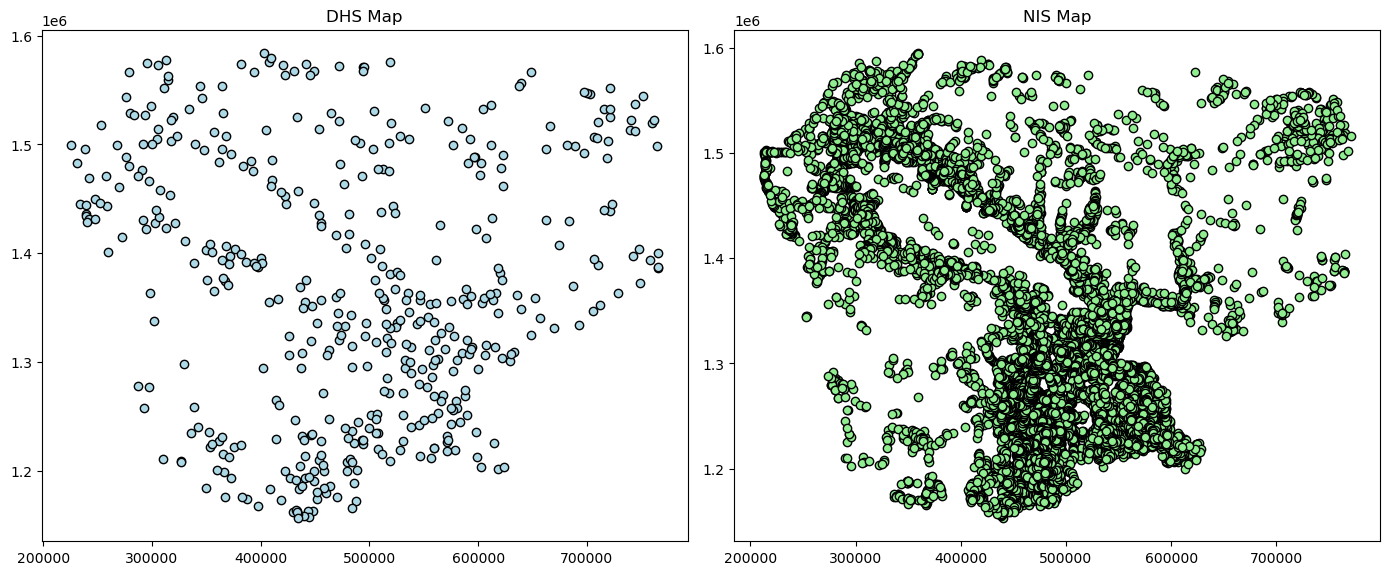

In [44]:

# Plotting the NIS and DHS maps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # high x wide in inches

dhs.plot(ax=axes[0], color='lightblue', edgecolor='black')
axes[0].set_title('DHS Map')

nis.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('NIS Map')

plt.tight_layout()
plt.show()
